In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.environ['KERAS_BACKEND'] = 'jax'
import keras
import joblib
from datetime import datetime, timedelta
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
from matplotlib.patches import Circle, Wedge
from matplotlib.collections import LineCollection
import matplotlib as mpl
from geopack import geopack as gp

Load IGRF coefficients ...


In [ ]:
# Font
mpl.rcParams['font.size'] = 12

ibm = LinearSegmentedColormap.from_list("ibm", ['#648eff', '#785eef', '#db267e', '#fd6000', '#ffaf00'], N=256)
ibm_divergent = LinearSegmentedColormap.from_list("ibm", [ibm(0), "#f7f7f7", ibm(160)], N=256)

In [ ]:
omni_full = pd.read_hdf('Data/OMNI/omni.h5')
symh = pd.read_hdf("Data/OMNI/omni_with_indices.h5")['SYM/H, nT']
omni_full = omni_full.merge(symh, on='Time tag')
omni_full = omni_full.loc[~omni_full.index.duplicated()]
omni_full = omni_full.resample('1min').interpolate()

In [4]:
omni = pd.read_hdf(f'Data/2015.03/df_with_history.h5')
best_features = np.load('Feature selection/L1 24 hours SQINV/42 features.npy', allow_pickle=True)
best_features = np.char.replace(best_features, '0.2-', '0.25-')
best_features = np.char.replace(best_features, '0.8-', '0.75-')
omni = omni[[col for col in best_features if ~np.isin(col, ['lg E', 'RAD', 'cosMLTcosMLAT', 'sinMLAT', 'sinMLTcosMLAT', 'PS'])]]
omni = omni.resample('1min').interpolate()

In [5]:
ts05_params = pd.DataFrame(np.loadtxt(f'Data/2015_OMNI_5m_with_TS05_variables.dat.txt'))

header = ['IYEAR', 'IDAY', 'IHOUR', 'MIN', 'BXGSM', 'BYGSM', 'BZGSM', 'VXGSE',
          'VYGSE', 'VZGSE', 'DEN', 'TEMP', 'SYMH', 'IMFFLAG', 'ISWFLAG', 'TILT',
          'Pdyn', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6']
ts05_params.columns = header
ts05_params['Time tag'] = ts05_params.agg(
    lambda x: datetime(year=int(x['IYEAR']), month=1, day=1) + \
        timedelta(days=int(x['IDAY'])-1, hours=int(x['IHOUR']), minutes=int(x['MIN'])),
    axis=1)
ts05_params = ts05_params.set_index('Time tag')
ts05_params = ts05_params.drop(columns=['IYEAR', 'IDAY', 'IHOUR', 'MIN'])

ts05_params = ts05_params[['Pdyn', 'SYMH', 'BYGSM', 'BZGSM', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6']]
ts05_params = ts05_params.resample('1min').interpolate()

In [39]:
time = datetime(2015, 3, 17, 4, 0)
# time = datetime(2015, 3, 17, 9, 10)
# time = datetime(2015, 3, 17, 23, 25)
# time = datetime(2015, 3, 17, 13, 35)
# time = datetime(2015, 3, 17, 14, 15)
# time = datetime(2015, 3, 18, 4, 0)
# time = datetime(2015, 3, 25, 4, 0)

In [40]:
omni_full_time = omni_full.loc[time]

In [41]:
ts05_params_time = ts05_params.loc[time]

In [42]:
# Bow shock model
imf_bz = omni_full_time['BZ, nT (GSM)']
beta = omni_full_time['Plasma beta']
mach_ms = omni_full_time['Magnetosonic Mach number']
sw_p_dyn = omni_full_time['Flow pressure, nPa']

a1 = 11.1266; a2 = 0.0010; a3 = -0.0005; a4 = 2.5966; a5 = 0.8182
a6 = -0.0170; a7 = -0.0122; a8 = 1.3007; a9 = -0.0049; a10 = -0.0328
a11 = 6.047; a12 = 1.029; a13 = 0.0231; a14 = -0.002

r0 = a1*(1+a2*imf_bz)*(1+a9*beta)*(1+a4*((a8-1)*mach_ms**2+2)/((a8+1)*mach_ms**2))*sw_p_dyn**(-1/a11)*0.5*(1+np.sign(imf_bz))+\
        a1*(1+a3*imf_bz)*(1+a9*beta)*(1+a4*((a8-1)*mach_ms**2+2)/((a8+1)*mach_ms**2))*sw_p_dyn**(-1/a11)*0.5*(1-np.sign(imf_bz))

alpha = a5*(1+a13*imf_bz)*(1+a7*sw_p_dyn)*(1+a10*np.log(1+beta))*(1+a14*mach_ms)*0.5*(1+np.sign(imf_bz))+\
        a5*(1+a6*imf_bz)*(1+a7*sw_p_dyn)*(1+a10*np.log(1+beta))*(1+a14*mach_ms)*0.5*(1-np.sign(imf_bz))

eps = a12

th_seeds = np.linspace(-np.pi/2, np.pi/2, 100)

xs_bow = []
zs_bow = []

for theta in th_seeds:
    r = r0*((1 + eps) / (1 + eps * np.cos(theta)))**alpha

    xs_bow.append(r * np.cos(theta))
    zs_bow.append(r * np.sin(theta))

In [43]:
# Shue
imf_bz = omni_full_time['BZ, nT (GSM)']
sw_p_dyn = omni_full_time['Flow pressure, nPa']

r0 = (11.4+0.013*imf_bz)*sw_p_dyn**(-1/6.6)*0.5*(1+np.sign(imf_bz)) + \
     (11.4+0.14*imf_bz)*sw_p_dyn**(-1/6.6)*0.5*(1-np.sign(imf_bz))

alpha = (0.58-0.010*imf_bz)*(1+0.010*sw_p_dyn)

th_seeds = np.linspace(-np.pi, np.pi, 100)

xs_mp = []
ys_mp = []

for theta in th_seeds:
    r = r0 * (2 / (1 + np.cos(theta)))**alpha

    xs_mp.append(r * np.cos(theta))
    ys_mp.append(r * np.sin(theta))

/tmp/ipykernel_2257810/2285655466.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  r = r0 * (2 / (1 + np.cos(theta)))**alpha


In [45]:
import numpy as np
import pandas as pd
from geopack import t96, t04

# Rationale:
# - gp.trace(...) follows the full 3D magnetic field, so lines can leave y=0.
# - To stay strictly in the GSM XZ plane, integrate only the projected field
#   (Bx, Bz) evaluated at y=0 instead of calling gp.trace(...). The geopack
#   package exposes the needed field evaluators separately: gp.igrf_gsm(...)
#   for the internal field and t96.t96(...) for the external field. :contentReference[oaicite:0]{index=0}

ut_sec = pd.Timestamp(time, tz="UTC").timestamp()

tilt = gp.recalc(ut_sec, vxgse=-400.0, vygse=0.0, vzgse=0.0)
print("Tilt:", np.rad2deg(tilt), "deg")

pdyn = float(omni_full_time["Flow pressure, nPa"])
symh = float(omni_full_time["SYM/H, nT"])
byimf = float(omni_full_time["BY, nT (GSM)"])
bzimf = float(omni_full_time["BZ, nT (GSM)"])
w1 = float(ts05_params_time["W1"])
w2 = float(ts05_params_time["W2"])
w3 = float(ts05_params_time["W3"])
w4 = float(ts05_params_time["W4"])
w5 = float(ts05_params_time["W5"])
w6 = float(ts05_params_time["W6"])

parmod = np.zeros(10, dtype=float)
parmod[0] = pdyn
parmod[1] = symh
parmod[2] = byimf
parmod[3] = bzimf
parmod[4] = w1
parmod[5] = w2
parmod[6] = w3
parmod[7] = w4
parmod[8] = w5
parmod[9] = w6

x_min, x_max = -20, 20
z_min, z_max = -12, 12

xs_seeds = np.arange(x_min, x_max, 2.5)
zs_seeds = np.arange(z_min, z_max, 2.5)

delta = 1.2          # target mean spacing between kept field lines
n_sample = 200       # number of points for uniform arclength resampling
r_exclude = 1.05     # avoid seeds inside Earth


def model_b_gsm_xz(gp, x, z, parmod, ps):
    """
    Total GSM magnetic field at (x, y=0, z), using:
      - internal: IGRF via gp.igrf_gsm(...)
      - external: T96  via t96.t96(...)

    Returns
    -------
    bx, by, bz : float
        Total field components in GSM, nT.

    Notes
    -----
    The geopack package provides separate evaluators for IGRF and T96, while
    gp.trace(...) traces the full 3D field. :contentReference[oaicite:1]{index=1}
    """
    x = float(x)
    z = float(z)
    y = 0.0

    bix, biy, biz = gp.igrf_gsm(x, y, z)
    # bex, bey, bez = t96.t96(parmod, ps, x, y, z)
    bex, bey, bez = t04.t04(parmod, ps, x, y, z)

    bx = bix + bex
    by = biy + bey
    bz = biz + bez
    return bx, by, bz


def trace_projected_xz(
    gp,
    x0,
    z0,
    parmod,
    ps,
    direction=1.0,
    ds=0.08,
    rlim=23.4,
    r0=1.0,
    maxloop=5000,
):
    """
    Integrate a 2D streamline in the GSM XZ plane using only (Bx, Bz) sampled at y=0.

    This is NOT a true 3D field-line trace.
    It is a meridional-plane streamline of the projected field.

    Returns
    -------
    x_line, y_line, z_line : np.ndarray
    """
    x = float(x0)
    z = float(z0)

    xs = [x]
    ys = [0.0]
    zs = [z]

    for _ in range(maxloop):
        r = np.hypot(x, z)
        if r < r0 or r > rlim:
            break

        bx, by, bz = model_b_gsm_xz(gp, x, z, parmod, ps)

        # project to XZ plane only
        bproj = np.hypot(bx, bz)
        if not np.isfinite(bproj) or bproj <= 1e-12:
            break

        x += direction * ds * bx / bproj
        z += direction * ds * bz / bproj

        xs.append(x)
        ys.append(0.0)
        zs.append(z)

    return np.asarray(xs), np.asarray(ys), np.asarray(zs)


def trace_field_line_xz(gp, x0, z0, parmod, ps, rlim=23.4, r0=1.0, maxloop=5000, ds=0.08):
    """
    Trace both directions in the projected XZ-plane field and join them.
    """
    xf, yf, zf = trace_projected_xz(
        gp, x0, z0, parmod, ps,
        direction=+1.0, ds=ds, rlim=rlim, r0=r0, maxloop=maxloop
    )

    xb, yb, zb = trace_projected_xz(
        gp, x0, z0, parmod, ps,
        direction=-1.0, ds=ds, rlim=rlim, r0=r0, maxloop=maxloop
    )

    x_line = np.concatenate([xb[::-1], xf[1:]])
    y_line = np.concatenate([yb[::-1], yf[1:]])
    z_line = np.concatenate([zb[::-1], zf[1:]])

    return x_line, y_line, z_line


def resample_curve_arclength(x, z, n=200):
    pts = np.column_stack([x, z])

    # remove repeated neighboring points to avoid zero-length segments
    d = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
    keep = np.ones(len(pts), dtype=bool)
    keep[1:] = d > 1e-10
    pts = pts[keep]

    if len(pts) < 2:
        return None

    seg = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
    s = np.concatenate([[0.0], np.cumsum(seg)])
    total = s[-1]

    if total <= 0:
        return None

    su = np.linspace(0.0, total, n)
    xu = np.interp(su, s, pts[:, 0])
    zu = np.interp(su, s, pts[:, 1])
    return np.column_stack([xu, zu])


def mean_line_distance(curve_a, curve_b):
    """
    Symmetric mean nearest-neighbor distance between two sampled curves.
    curve_a, curve_b: arrays of shape (N, 2), (M, 2)
    """
    dx = curve_a[:, None, 0] - curve_b[None, :, 0]
    dz = curve_a[:, None, 1] - curve_b[None, :, 1]
    dist = np.hypot(dx, dz)

    a_to_b = dist.min(axis=1).mean()
    b_to_a = dist.min(axis=0).mean()
    return 0.5 * (a_to_b + b_to_a)


# ---- trace all candidate XZ-plane streamlines first ----
candidates = []

for ix, x0 in enumerate(xs_seeds):
    for iz, z0 in enumerate(zs_seeds):
        if (ix + iz) % 2 == 1:
            continue

        if np.hypot(x0, z0) < r_exclude:
            continue

        x_line, y_line, z_line = trace_field_line_xz(
            gp, x0, z0, parmod, tilt,
            rlim=23.4, r0=1.0, maxloop=5000, ds=0.08
        )

        curve = resample_curve_arclength(x_line, z_line, n=n_sample)

        if curve is None or len(x_line) < 2:
            continue

        candidates.append({
            "seed": (x0, z0),
            "x": x_line,
            "y": y_line,   # guaranteed to be 0 everywhere
            "z": z_line,
            "curve": curve,
        })

# optional: choose a stable ordering
candidates.sort(key=lambda c: -np.hypot(c["seed"][0], c["seed"][1]))

# ---- greedy selection with target spacing delta ----
selected = []
selected_curves = []

for cand in candidates:
    if not selected_curves:
        selected.append(cand)
        selected_curves.append(cand["curve"])
        continue

    dmin = min(mean_line_distance(cand["curve"], old) for old in selected_curves)

    if dmin >= delta:
        selected.append(cand)
        selected_curves.append(cand["curve"])

# output in your original format
xxs = [c["x"] for c in selected]
yys = [c["y"] for c in selected]
zzs = [c["z"] for c in selected]

print(f"Kept {len(xxs)} XZ-plane streamlines out of {len(candidates)} candidates")
print("All y arrays are exactly zero:", all(np.allclose(y, 0.0) for y in yys))

Tilt: -10.846699035086289 deg
Kept 27 XZ-plane streamlines out of 80 candidates
All y arrays are exactly zero: True


In [ ]:
def add_stopgrad_base(inputs):
    base, dist = inputs
    return keras.ops.stop_gradient(base) + dist

co = {'loss': lambda x: None, 'pearson': lambda x: None, 'add_stopgrad_base': add_stopgrad_base}

model = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p50.keras', custom_objects=co)
model_25 = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p25.keras', custom_objects=co)
model_75 = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p75.keras', custom_objects=co)

scaler = joblib.load('Models/genet-0.1.1.scaler.save')

def relu(x):
    return np.maximum(x, 0)

In [47]:
omni_time = omni[time:time]

In [48]:
xs = np.linspace(-20, 20, 320)
ys = np.linspace(-20, 20, 320)
zs = np.linspace(-12, 12, 192)

In [49]:
def omnidir_flux(dir_flux):
    num = np.sum([(10**dir_flux[..., j] - 1) * np.sin(np.deg2rad(10+20*j)) for j in range(9)], axis=0)
    den = np.sum(np.sin(np.deg2rad(np.arange(10, 180, 20))))
    omni_flux = np.log10(num / den + 1)
    return omni_flux

def pancake_index_1(dir_flux):
    num = 2 * (10**dir_flux[..., 4] - 1)
    den = (10**dir_flux[..., 0] - 1) + (10**dir_flux[..., 8] - 1)

    with np.errstate(divide='ignore', invalid='ignore'):
        pi = num / den
    pi[(num == 0) & (den == 0)] = 1

    return pi

def pancake_index_2(dir_flux):
    num = 2 * (10**dir_flux[..., 4] - 1)
    den = (10**dir_flux[..., 2] - 1) + (10**dir_flux[..., 6] - 1)

    with np.errstate(divide='ignore', invalid='ignore'):
        pi = num / den
    pi[(num == 0) & (den == 0)] = 1

    return pi

def cigar_index(dir_flux):
    num = 10**dir_flux[..., 0] - 1
    den = 10**dir_flux[..., 8] - 1

    with np.errstate(divide='ignore', invalid='ignore'):
        ci = num / den
    ci[(num == 0) & (den == 0)] = 1

    return ci

In [50]:
# energy = 50000
energy = 20000
# energy = 100

In [51]:
# XZ
X, Z = np.meshgrid(xs, zs)
n = len(X.ravel())

r = (X**2 + Z**2)**0.5 * 6378
lat = np.asin(Z * 6378 / r)
mlt = (X > 0).astype(float) * 12

slat = np.sin(lat)
smlt_clat = np.sin(mlt*np.pi/12) * np.cos(lat)
cmlt_clat = np.cos(mlt*np.pi/12) * np.cos(lat)

input = pd.DataFrame({
    'RAD': r.ravel(),
    'sinMLAT': slat.ravel(),
    'sinMLTcosMLAT': smlt_clat.ravel(),
    'cosMLTcosMLAT': cmlt_clat.ravel(),
    'lg E': np.log10(energy),
    'PS': tilt
    }, index=np.repeat(omni_time.index, n))
input = input.merge(omni_time, on='Time tag')
input = input[scaler.feature_names_in_]
input[input.columns] = scaler.transform(input[input.columns])

base_features = [1, 2, 3, 4, 0, 5]
_, flux = model.predict([input.iloc[:, base_features], input], batch_size=2**17, verbose=False)
flux = flux.reshape(len(zs), len(xs), 9)
flux = relu(flux)

_, flux_25 = model_25.predict([input.iloc[:, base_features], input], batch_size=2**17, verbose=False)
flux_25 = flux_25.reshape(len(zs), len(xs), 9)
flux_25 = relu(flux_25)

_, flux_75 = model_75.predict([input.iloc[:, base_features], input], batch_size=2**17, verbose=False)
flux_75 = flux_75.reshape(len(zs), len(xs), 9)
flux_75 = relu(flux_75)

flux_o = omnidir_flux(flux)
flux_o_25 = omnidir_flux(flux_25)
flux_o_75 = omnidir_flux(flux_75)
pi_1 = pancake_index_1(flux)
pi_2 = pancake_index_2(flux)
ci = cigar_index(flux)

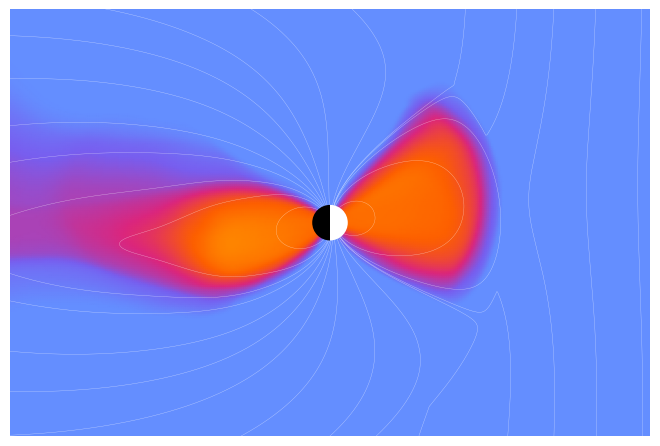

In [ ]:
fig, ax = plt.subplots()
ax.set_aspect(1)

pcm = ax.pcolormesh(xs, zs, flux_o,
# pcm = ax.pcolormesh(xs, zs, flux_o_25,
# pcm = ax.pcolormesh(xs, zs, flux_o_75,
# pcm = ax.pcolormesh(xs, zs, flux_o_75 - flux_o_25,
                    shading='gouraud',
                    cmap=ibm,
                    vmin=0, vmax=6
                    # vmin=0, vmax=5
                    # vmin=7, vmax=10
                    # vmin=4, vmax=7
              )

if energy < 40000:
    ax.add_patch(Circle((0, 0), 3, facecolor='w', edgecolor='none'))

ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none', zorder=100000))
ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none', zorder=100000))

for l in range(len(xxs)):
    ax.plot(xxs[l], zzs[l], linewidth=0.25, alpha=0.6, c='w')

if energy < 200:
    plt.plot(xs_bow, zs_bow, color='k', linestyle='--', linewidth=0.5)

# plt.plot(xs_mp, ys_mp, color='k', linestyle='--', linewidth=0.5)

ax.set_xlim(-18, 18)
ax.set_ylim(-12, 12)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

fig.savefig(f'Plots/storm_{str(time).replace(":", "-")}_q1.pdf', bbox_inches='tight', pad_inches=0)
# fig.savefig(f'Plots/storm_{str(time).replace(":", "-")}_q3.pdf', bbox_inches='tight', pad_inches=0)

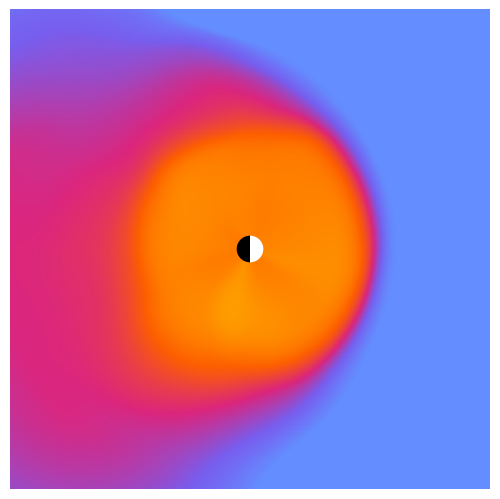

In [86]:
fig, ax = plt.subplots()
ax.set_aspect(1)

ax.pcolormesh(xs, ys, flux_o,
# ax.pcolormesh(xs, ys, flux[..., 1] + (45 - 30) / (50 - 30) * (flux[..., 2] - flux[..., 1]),
              shading='gouraud',
              cmap=ibm,
              vmin=0, vmax=6
            #   vmin=7, vmax=10
            #   vmin=4, vmax=7.5
              )

if energy < 40000:
    ax.add_patch(Circle((0, 0), 3, facecolor='w', edgecolor='none'))

# plt.plot(xs_mp, ys_mp, color='k', linestyle='--', linewidth=0.5)

ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none'))
ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none'))

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(-18, 18)
ax.set_ylim(-18, 18)

# ax.set_xlim(18, -18)
# ax.set_ylim(18, -18)

# ax.set_xlim(9, -9)
# ax.set_ylim(9, -9)

fig.tight_layout()

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

# fig.savefig('Plots/energy_100_xy.pdf', bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/pitch_angle_90.pdf', bbox_inches='tight', pad_inches=0)

# fig.savefig('Plots/genet_10kev.png', bbox_inches='tight', pad_inches=0, dpi=600)
fig.savefig(f'Plots/storm_{str(time).replace(":", "-")}_xy.pdf', bbox_inches='tight', pad_inches=0)

# Input parameters

In [75]:
omni_storm = pd.read_hdf(f'Data/2015.03/df_with_history.h5')
omni_storm = omni_storm[datetime(2015, 3, 17, 0):datetime(2015, 3, 18, 12)]

In [ ]:
hp30 = pd.read_hdf('Data/OMNI/omni.h5')['Hp30'].dropna()
hp30 = hp30[datetime(2015, 3, 17, 0):datetime(2015, 3, 18, 12)]

In [77]:
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import numpy as np

def add_shared_vline(fig, axes, x, **kwargs):
    axes = np.atleast_1d(axes).ravel().tolist()
    if not axes:
        raise ValueError("axes must not be empty")

    xnum = mdates.date2num(x)
    line = mlines.Line2D([], [], transform=fig.transFigure, clip_on=False, **kwargs)
    fig.add_artist(line)

    def _update(_=None):
        xfig = fig.transFigure.inverted().transform(
            axes[0].transData.transform((xnum, 0))
        )[0]
        positions = [a.get_position() for a in axes]
        y0 = min(p.y0 for p in positions)
        y1 = max(p.y1 for p in positions)
        line.set_data([xfig, xfig], [y0, y1])

    _update()
    fig.canvas.mpl_connect("draw_event", _update)
    return line

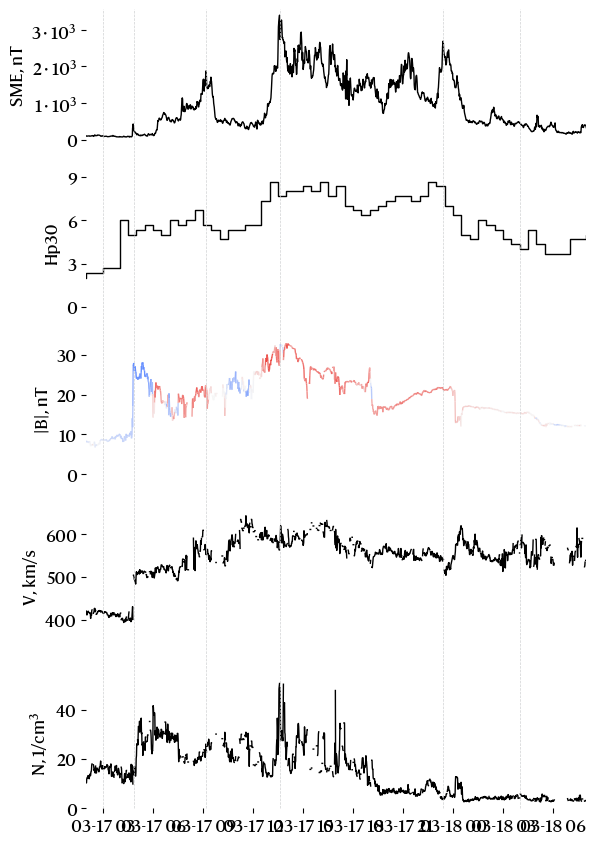

In [97]:
fig, ax = plt.subplots(5, 1, figsize=(5, 7 * 597.0726 / 522.8906))

# SME
ax[0].plot(omni_storm['SME, nT'], c='k', linewidth=1)
ax[0].set_ylim(0)
ax[0].set_yticks(np.arange(0, 3001, 1000))
ax[0].set_yticklabels(['0', '$1 \cdot 10^3$', '$2 \cdot 10^3$', '$3 \cdot 10^3$'], math_fontfamily='custom')
ax[0].set_ylabel('SME, nT')

# Hp30
# ax[1].step(hp30.index, hp30, where='post', c='k', linewidth=1)
ax[1].step(hp30.index, hp30, where='pre', c='k', linewidth=1)
ax[1].set_ylim(0)
ax[1].set_yticks(np.arange(0, 10, 3))
ax[1].set_ylabel('Hp30')

# B
x = mpl.dates.date2num(omni_storm.index)
y = omni_storm['Field magnitude average, nT'].to_numpy()
c = -omni_storm['BZ, nT (GSM)'].to_numpy()
pts = np.array([x, y]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap=ibm_divergent, norm=mpl.colors.Normalize(-25, 25))
lc.set_array(c[:-1])
lc.set_linewidth(1)
ax[2].add_collection(lc)
ax[2].set_ylim(np.nanmin(y), np.nanmax(y))
ax[2].xaxis_date()
ax[2].set_yticks(np.arange(0, 40, 10))
ax[2].set_ylabel('|B|, nT')

# V_SW
ax[3].plot(omni_storm['Speed, km/s'], c='k', linewidth=1)
ax[3].set_ylim(350)
ax[3].set_yticks(np.arange(400, 601, 100))
ax[3].set_ylabel('V, km/s')

# N_SW
ax[4].plot(omni_storm['Proton Density, n/cc'], c='k', linewidth=1)
ax[4].set_ylim(0)
# ax[4].set_yticks(np.arange(400, 601, 100))
ax[4].set_ylabel('N, 1/cm$^3$', math_fontfamily='custom')

for axis in ax:
    axis.set_xlim(datetime(2015, 3, 17, 2), datetime(2015, 3, 18, 8))

    for spine in axis.spines.values():
        spine.set_visible(False)

for i in range(4):
    ax[i].set_xticks([])

c = '#d0d2d3'
add_shared_vline(fig, ax, datetime(2015, 3, 17, 3), color=c, linestyle='--', linewidth=0.5)
# add_shared_vline(fig, ax, datetime(2015, 3, 17, 5, 10), color=c, linestyle='--', linewidth=0.5)
add_shared_vline(fig, ax, datetime(2015, 3, 17, 4, 50), color=c, linestyle='--', linewidth=0.5)
add_shared_vline(fig, ax, datetime(2015, 3, 17, 9, 10), color=c, linestyle='--', linewidth=0.5)
add_shared_vline(fig, ax, datetime(2015, 3, 17, 13, 35), color=c, linestyle='--', linewidth=0.5)
# add_shared_vline(fig, ax, datetime(2015, 3, 17, 15, 50), color=c, linestyle='--', linewidth=0.5)
add_shared_vline(fig, ax, datetime(2015, 3, 17, 23, 25), color=c, linestyle='--', linewidth=0.5)
add_shared_vline(fig, ax, datetime(2015, 3, 18, 4), color=c, linestyle='--', linewidth=0.5)

fig.tight_layout()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

fig.savefig('Plots/st_patrick_drivers.pdf', bbox_inches='tight', pad_inches=0)

# Animation

In [28]:
time_0 = datetime(2015, 3, 17, 4, 0)

for i in range(97):
# for i in range(40, 97):
# def proc_frame(i):
    print(i)
    time = time_0 + i * timedelta(minutes=15)

    omni_full_time = omni_full.loc[time]
    ts05_params_time = ts05_params.loc[time]

    import numpy as np
    import pandas as pd
    from geopack import t96, t04

    # Rationale:
    # - gp.trace(...) follows the full 3D magnetic field, so lines can leave y=0.
    # - To stay strictly in the GSM XZ plane, integrate only the projected field
    #   (Bx, Bz) evaluated at y=0 instead of calling gp.trace(...). The geopack
    #   package exposes the needed field evaluators separately: gp.igrf_gsm(...)
    #   for the internal field and t96.t96(...) for the external field. :contentReference[oaicite:0]{index=0}

    ut_sec = pd.Timestamp(time, tz="UTC").timestamp()

    tilt = gp.recalc(ut_sec, vxgse=-400.0, vygse=0.0, vzgse=0.0)
    print("Tilt:", np.rad2deg(tilt), "deg")

    pdyn = float(omni_full_time["Flow pressure, nPa"])
    symh = float(omni_full_time["SYM/H, nT"])
    byimf = float(omni_full_time["BY, nT (GSM)"])
    bzimf = float(omni_full_time["BZ, nT (GSM)"])
    w1 = float(ts05_params_time["W1"])
    w2 = float(ts05_params_time["W2"])
    w3 = float(ts05_params_time["W3"])
    w4 = float(ts05_params_time["W4"])
    w5 = float(ts05_params_time["W5"])
    w6 = float(ts05_params_time["W6"])

    parmod = np.zeros(10, dtype=float)
    parmod[0] = pdyn
    parmod[1] = symh
    parmod[2] = byimf
    parmod[3] = bzimf
    parmod[4] = w1
    parmod[5] = w2
    parmod[6] = w3
    parmod[7] = w4
    parmod[8] = w5
    parmod[9] = w6

    x_min, x_max = -20, 20
    z_min, z_max = -20, 20

    # xs_seeds = np.arange(x_min, x_max, 2.5)
    # zs_seeds = np.arange(z_min, z_max, 2.5)

    xs_seeds = np.arange(x_min, x_max, 4)
    zs_seeds = np.arange(z_min, z_max, 4)

    delta = 1.2          # target mean spacing between kept field lines
    n_sample = 200       # number of points for uniform arclength resampling
    r_exclude = 1.05     # avoid seeds inside Earth


    def model_b_gsm_xz(gp, x, z, parmod, ps):
        """
        Total GSM magnetic field at (x, y=0, z), using:
        - internal: IGRF via gp.igrf_gsm(...)
        - external: T96  via t96.t96(...)

        Returns
        -------
        bx, by, bz : float
            Total field components in GSM, nT.

        Notes
        -----
        The geopack package provides separate evaluators for IGRF and T96, while
        gp.trace(...) traces the full 3D field. :contentReference[oaicite:1]{index=1}
        """
        x = float(x)
        z = float(z)
        y = 0.0

        bix, biy, biz = gp.igrf_gsm(x, y, z)
        # bex, bey, bez = t96.t96(parmod, ps, x, y, z)
        bex, bey, bez = t04.t04(parmod, ps, x, y, z)

        bx = bix + bex
        by = biy + bey
        bz = biz + bez
        return bx, by, bz


    def trace_projected_xz(
        gp,
        x0,
        z0,
        parmod,
        ps,
        direction=1.0,
        ds=0.08,
        rlim=23.4,
        r0=1.0,
        maxloop=5000,
    ):
        """
        Integrate a 2D streamline in the GSM XZ plane using only (Bx, Bz) sampled at y=0.

        This is NOT a true 3D field-line trace.
        It is a meridional-plane streamline of the projected field.

        Returns
        -------
        x_line, y_line, z_line : np.ndarray
        """
        x = float(x0)
        y = float(0)
        z = float(z0)

        xs = [x]
        ys = [0.0]
        zs = [z]

        for _ in range(maxloop):
            r = np.hypot(x, z)
            if r < r0 or r > rlim:
                break

            bx, by, bz = model_b_gsm_xz(gp, x, z, parmod, ps)

            # project to XZ plane only
            bproj = np.hypot(bx, bz)
            if not np.isfinite(bproj) or bproj <= 1e-12:
                break

            x += direction * ds * bx / bproj
            # y += direction * ds * by / bproj
            z += direction * ds * bz / bproj

            xs.append(x)
            # ys.append(y)
            ys.append(0.0)
            zs.append(z)

        return np.asarray(xs), np.asarray(ys), np.asarray(zs)


    def trace_field_line_xz(gp, x0, z0, parmod, ps, rlim=23.4, r0=1.0, maxloop=5000, ds=0.08):
        """
        Trace both directions in the projected XZ-plane field and join them.
        """
        xf, yf, zf = trace_projected_xz(
            gp, x0, z0, parmod, ps,
            direction=+1.0, ds=ds, rlim=rlim, r0=r0, maxloop=maxloop
        )

        xb, yb, zb = trace_projected_xz(
            gp, x0, z0, parmod, ps,
            direction=-1.0, ds=ds, rlim=rlim, r0=r0, maxloop=maxloop
        )

        x_line = np.concatenate([xb[::-1], xf[1:]])
        y_line = np.concatenate([yb[::-1], yf[1:]])
        z_line = np.concatenate([zb[::-1], zf[1:]])

        return x_line, y_line, z_line


    def resample_curve_arclength(x, z, n=200):
        pts = np.column_stack([x, z])

        # remove repeated neighboring points to avoid zero-length segments
        d = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
        keep = np.ones(len(pts), dtype=bool)
        keep[1:] = d > 1e-10
        pts = pts[keep]

        if len(pts) < 2:
            return None

        seg = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
        s = np.concatenate([[0.0], np.cumsum(seg)])
        total = s[-1]

        if total <= 0:
            return None

        su = np.linspace(0.0, total, n)
        xu = np.interp(su, s, pts[:, 0])
        zu = np.interp(su, s, pts[:, 1])
        return np.column_stack([xu, zu])


    def mean_line_distance(curve_a, curve_b):
        """
        Symmetric mean nearest-neighbor distance between two sampled curves.
        curve_a, curve_b: arrays of shape (N, 2), (M, 2)
        """
        dx = curve_a[:, None, 0] - curve_b[None, :, 0]
        dz = curve_a[:, None, 1] - curve_b[None, :, 1]
        dist = np.hypot(dx, dz)

        a_to_b = dist.min(axis=1).mean()
        b_to_a = dist.min(axis=0).mean()
        return 0.5 * (a_to_b + b_to_a)


    # ---- trace all candidate XZ-plane streamlines first ----
    candidates = []

    for ix, x0 in enumerate(xs_seeds):
        for iz, z0 in enumerate(zs_seeds):
            if (ix + iz) % 2 == 1:
                continue

            if np.hypot(x0, z0) < r_exclude:
                continue

            x_line, y_line, z_line = trace_field_line_xz(
                gp, x0, z0, parmod, tilt,
                rlim=23.4, r0=1.0, maxloop=5000, ds=0.08
            )

            curve = resample_curve_arclength(x_line, z_line, n=n_sample)

            if curve is None or len(x_line) < 2:
                continue

            candidates.append({
                "seed": (x0, z0),
                "x": x_line,
                "y": y_line,   # guaranteed to be 0 everywhere
                "z": z_line,
                "curve": curve,
            })

    # optional: choose a stable ordering
    candidates.sort(key=lambda c: -np.hypot(c["seed"][0], c["seed"][1]))

    # ---- greedy selection with target spacing delta ----
    selected = []
    selected_curves = []

    for cand in candidates:
        if not selected_curves:
            selected.append(cand)
            selected_curves.append(cand["curve"])
            continue

        dmin = min(mean_line_distance(cand["curve"], old) for old in selected_curves)

        if dmin >= delta:
            selected.append(cand)
            selected_curves.append(cand["curve"])

    # output in your original format
    xxs = [c["x"] for c in selected]
    yys = [c["y"] for c in selected]
    zzs = [c["z"] for c in selected]

    print(f"Kept {len(xxs)} XZ-plane streamlines out of {len(candidates)} candidates")
    print("All y arrays are exactly zero:", all(np.allclose(y, 0.0) for y in yys))

    omni_time = omni[time:time]

    xs = np.linspace(-18, 18, 320)
    ys = np.linspace(-18, 18, 320)
    zs = np.linspace(-18, 18, 320)

    # XZ
    X, Z = np.meshgrid(xs, zs)
    n = len(X.ravel())

    r = (X**2 + Z**2)**0.5 * 6378
    lat = np.asin(Z * 6378 / r)
    mlt = (X > 0).astype(float) * 12

    slat = np.sin(lat)
    smlt_clat = np.sin(mlt*np.pi/12) * np.cos(lat)
    cmlt_clat = np.cos(mlt*np.pi/12) * np.cos(lat)

    input = pd.DataFrame({
        'RAD': r.ravel(),
        'sinMLAT': slat.ravel(),
        'sinMLTcosMLAT': smlt_clat.ravel(),
        'cosMLTcosMLAT': cmlt_clat.ravel(),
        'lg E': np.log10(energy),
        'PS': tilt
        }, index=np.repeat(omni_time.index, n))
    input = input.merge(omni_time, on='Time tag')
    input = input[scaler.feature_names_in_]
    input[input.columns] = scaler.transform(input[input.columns])

    base_features = [1, 2, 3, 4, 0, 5]
    _, flux = model.predict([input.iloc[:, base_features], input], batch_size=2**17, verbose=False)
    flux = flux.reshape(len(zs), len(xs), 9)
    flux = relu(flux)

    flux_o = omnidir_flux(flux)
    pi_1 = pancake_index_1(flux)
    pi_2 = pancake_index_2(flux)
    ci = cigar_index(flux)

    # fig, ax = plt.subplots()
    # ax.set_aspect(1)

    # pcm = ax.pcolormesh(xs, zs, flux_o,
    #                     shading='gouraud',
    #                     cmap=ibm,
    #                     vmin=0, vmax=6
    #                     # vmin=0, vmax=5
    #                     # vmin=7, vmax=10
    #                     # vmin=4, vmax=7
    #           )

    # if energy < 40000:
    #     ax.add_patch(Circle((0, 0), 3, facecolor='w', edgecolor='none'))

    # ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none', zorder=100000))
    # ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none', zorder=100000))

    # for l in range(len(xxs)):
    #     ax.plot(xxs[l], zzs[l], linewidth=0.25, alpha=1, c='w')

    # if energy < 200:
    #     plt.plot(xs_bow, zs_bow, color='k', linestyle='--', linewidth=0.5)

    # # plt.plot(xs_mp, ys_mp, color='k', linestyle='--', linewidth=0.5)

    # ax.set_xlim(-18, 18)
    # ax.set_ylim(-12, 12)

    # ax.set_xticks([])
    # ax.set_yticks([])
    # for spine in ax.spines.values():
    #     spine.set_visible(False)

    # fig.tight_layout()

    # fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    # fig.savefig(f'Animations/Storm/storm_{i}.png', bbox_inches='tight', pad_inches=0, dpi=600)

    fig, ax = plt.subplots()
    ax.set_aspect(1)

    pcm = ax.pcolormesh(xs, zs, flux_o,
                        shading='gouraud',
                        vmin=0, vmax=6
                        # vmin=0, vmax=5
                        # vmin=7, vmax=10
                        # vmin=4, vmax=7
              )

    if energy < 40000:
        ax.add_patch(Circle((0, 0), 3, facecolor='w', edgecolor='none'))

    ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none', zorder=100000))
    ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none', zorder=100000))

    for l in range(len(xxs)):
        # filter = yys[l] < 0.5
        # ax.plot(xxs[l][filter], zzs[l][filter], linewidth=1, alpha=1, c='w')
        ax.plot(xxs[l], zzs[l], linewidth=1, alpha=1, c='w')

    if energy < 200:
        plt.plot(xs_bow, zs_bow, color='k', linestyle='--', linewidth=0.5)

    # plt.plot(xs_mp, ys_mp, color='k', linestyle='--', linewidth=0.5)

    ax.set_xlim(-18, 18)
    ax.set_ylim(-18, 18)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    
    fig.savefig(f'Animations/Storm viridis/storm_{i}.png', bbox_inches='tight', pad_inches=0, dpi=300)

    plt.close(fig)

    print("Done", i)

# import multiprocessing as mp
# pool = mp.Pool(32)
# pool.map(proc_frame, range(97))

0
Tilt: -10.846699035086289 deg
Kept 23 XZ-plane streamlines out of 48 candidates
All y arrays are exactly zero: True
Done 0
1
Tilt: -10.985544809786225 deg
Kept 24 XZ-plane streamlines out of 48 candidates
All y arrays are exactly zero: True
Done 1
2
Tilt: -11.083202854011233 deg
Kept 23 XZ-plane streamlines out of 48 candidates
All y arrays are exactly zero: True
Done 2
3
Tilt: -11.139196084163602 deg
Kept 22 XZ-plane streamlines out of 48 candidates
All y arrays are exactly zero: True
Done 3
4
Tilt: -11.153242838097581 deg
Kept 23 XZ-plane streamlines out of 48 candidates
All y arrays are exactly zero: True
Done 4
5
Tilt: -11.1252590162407 deg
Kept 22 XZ-plane streamlines out of 48 candidates
All y arrays are exactly zero: True
Done 5
6
Tilt: -11.055358700663206 deg
Kept 22 XZ-plane streamlines out of 48 candidates
All y arrays are exactly zero: True
Done 6
7
Tilt: -10.943853226747457 deg
Kept 23 XZ-plane streamlines out of 48 candidates
All y arrays are exactly zero: True
Done 7
8


In [29]:
import imageio.v2 as imageio
from pathlib import Path

folder = Path("Animations/Storm viridis")
images = folder.glob("*.png")

with imageio.get_writer("Animations/Storm (T05, fewer).mp4", fps=8) as writer:
    for img_path in images:
        writer.append_data(imageio.imread(img_path))

/usr/lib/python3.11/subprocess.py:1834: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


# PAD

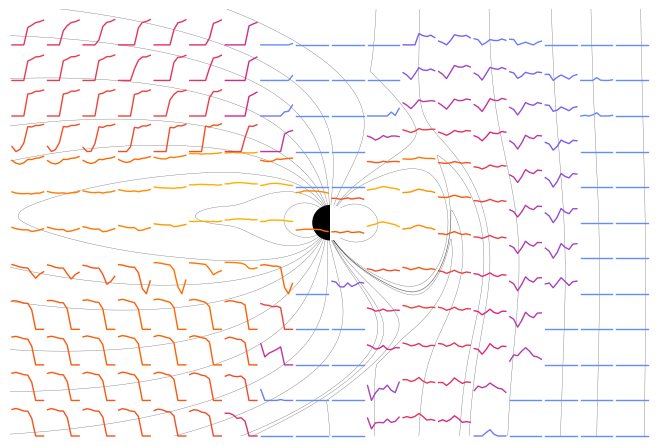

In [35]:
fig, ax = plt.subplots()
ax.set_aspect("equal")

def cell_axes(ax, col, row):
    x = -18 + 2 * col
    y = -12 + 2 * row

    child = ax.inset_axes(
        [x, y, 2, 2],
        transform=ax.transData
    )
    child.set_axis_off()
    return child

def pred_point(x, z):
    r = np.hypot(x, z) * 6378

    if r == 0:
        raise ValueError("x = z = 0 gives an undefined latitude.")

    lat = np.arcsin(z * 6378 / r)
    mlt = 12.0 if x > 0 else 0.0

    sin_mlat = np.sin(lat)
    sin_mlt_cos_mlat = np.sin(mlt * np.pi / 12) * np.cos(lat)
    cos_mlt_cos_mlat = np.cos(mlt * np.pi / 12) * np.cos(lat)

    # One spatial point for every timestamp in omni_time
    n_times = len(omni_time)

    model_input = pd.DataFrame(
        {
            "RAD": np.full(n_times, r),
            "sinMLAT": np.full(n_times, sin_mlat),
            "sinMLTcosMLAT": np.full(n_times, sin_mlt_cos_mlat),
            "cosMLTcosMLAT": np.full(n_times, cos_mlt_cos_mlat),
            "lg E": np.full(n_times, np.log10(energy)),
            "PS": np.full(n_times, tilt),
        },
        index=omni_time.index,
    )

    model_input.index.name = "Time tag"
    model_input = model_input.merge(
        omni_time,
        left_index=True,
        right_index=True,
    )

    model_input = model_input[scaler.feature_names_in_]
    model_input.loc[:, :] = scaler.transform(model_input)

    base_features = [1, 2, 3, 4, 0, 5]

    _, flux = model.predict(
        [
            model_input.iloc[:, base_features],
            model_input,
        ],
        batch_size=2**17,
        verbose=False,
    )

    # Shape: (number of timestamps, 9)
    flux = relu(flux)

    return flux

for col in range(18):
    for row in range(12):
        cell_ax = cell_axes(ax, col=col, row=row)

        x = -18 + 2 * col + 1
        y = -12 + 2 * row + 1
        fluxes = pred_point(x, y)[0, :]
        flux_o = omnidir_flux(fluxes)

        cell_ax.plot(np.arange(10, 180, 20), fluxes, linewidth=1, color=ibm(int(256 * flux_o / 6)), clip_on=False)
        # cell_ax.plot(np.arange(10, 180, 20), fluxes, linewidth=1, color=ibm(int(256 * (flux_o-4) / 4)), clip_on=False)

        # cell_ax.set_xlim(10, 170)
        cell_ax.set_xlim(0, 180)
        cell_ax.set_ylim(0, 6)
        # cell_ax.set_ylim(7, 8)

ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none', zorder=1))
ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none', zorder=1))

for l in range(len(xxs)):
    ax.plot(xxs[l], zzs[l], linewidth=0.25, alpha=0.6, c='k', zorder=0)

xlim = (-18, 18)
ylim = (-12, 12)

# vertical = ax.vlines(range(-18, 19, 2), ymin=ylim[0], ymax=ylim[1], linewidth=0.25, color="#bcbec0", clip_on=False, alpha=0.6)
# horizontal = ax.hlines(range(-12, 13, 2), xmin=xlim[0], xmax=xlim[1], linewidth=0.25, color="#bcbec0", clip_on=False, alpha=0.6)
# vertical.set_capstyle("butt")
# horizontal.set_capstyle("butt")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

# fig.savefig(f'Plots/pads_storm_{str(time).replace(":", "-")}.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

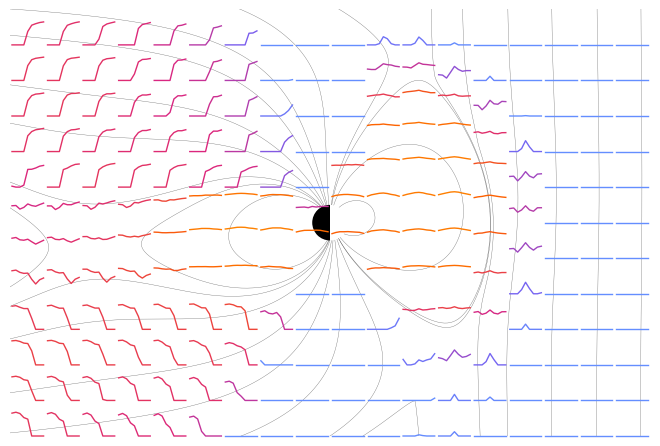

In [52]:
# 20 keV
fig, ax = plt.subplots()
ax.set_aspect("equal")

def cell_axes(ax, col, row):
    x = -18 + 2 * col
    y = -12 + 2 * row

    child = ax.inset_axes(
        [x, y, 2, 2],
        transform=ax.transData
    )
    child.set_axis_off()
    return child

def pred_point(x, z):
    r = np.hypot(x, z) * 6378

    if r == 0:
        raise ValueError("x = z = 0 gives an undefined latitude.")

    lat = np.arcsin(z * 6378 / r)
    mlt = 12.0 if x > 0 else 0.0

    sin_mlat = np.sin(lat)
    sin_mlt_cos_mlat = np.sin(mlt * np.pi / 12) * np.cos(lat)
    cos_mlt_cos_mlat = np.cos(mlt * np.pi / 12) * np.cos(lat)

    # One spatial point for every timestamp in omni_time
    n_times = len(omni_time)

    model_input = pd.DataFrame(
        {
            "RAD": np.full(n_times, r),
            "sinMLAT": np.full(n_times, sin_mlat),
            "sinMLTcosMLAT": np.full(n_times, sin_mlt_cos_mlat),
            "cosMLTcosMLAT": np.full(n_times, cos_mlt_cos_mlat),
            "lg E": np.full(n_times, np.log10(energy)),
            "PS": np.full(n_times, tilt),
        },
        index=omni_time.index,
    )

    model_input.index.name = "Time tag"
    model_input = model_input.merge(
        omni_time,
        left_index=True,
        right_index=True,
    )

    model_input = model_input[scaler.feature_names_in_]
    model_input.loc[:, :] = scaler.transform(model_input)

    base_features = [1, 2, 3, 4, 0, 5]

    _, flux = model.predict(
        [
            model_input.iloc[:, base_features],
            model_input,
        ],
        batch_size=2**17,
        verbose=False,
    )

    # Shape: (number of timestamps, 9)
    flux = relu(flux)

    return flux

for col in range(18):
    for row in range(12):
        cell_ax = cell_axes(ax, col=col, row=row)

        x = -18 + 2 * col + 1
        y = -12 + 2 * row + 1
        fluxes = pred_point(x, y)[0, :]
        flux_o = omnidir_flux(fluxes)

        cell_ax.plot(np.arange(10, 180, 20), fluxes, linewidth=1, color=ibm(int(256 * flux_o / 7)), clip_on=False)
        # cell_ax.plot(np.arange(10, 180, 20), fluxes, linewidth=1, color=ibm(int(256 * (flux_o-4) / 4)), clip_on=False)

        # cell_ax.set_xlim(10, 170)
        cell_ax.set_xlim(0, 180)
        cell_ax.set_ylim(0, 7)
        # cell_ax.set_ylim(7, 8)

ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none', zorder=1))
ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none', zorder=1))

for l in range(len(xxs)):
    ax.plot(xxs[l], zzs[l], linewidth=0.25, alpha=0.6, c='k', zorder=0)

xlim = (-18, 18)
ylim = (-12, 12)

# vertical = ax.vlines(range(-18, 19, 2), ymin=ylim[0], ymax=ylim[1], linewidth=0.25, color="#bcbec0", clip_on=False, alpha=0.6)
# horizontal = ax.hlines(range(-12, 13, 2), xmin=xlim[0], xmax=xlim[1], linewidth=0.25, color="#bcbec0", clip_on=False, alpha=0.6)
# vertical.set_capstyle("butt")
# horizontal.set_capstyle("butt")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

fig.savefig(f'Plots/pads_storm_20keV_{str(time).replace(":", "-")}.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

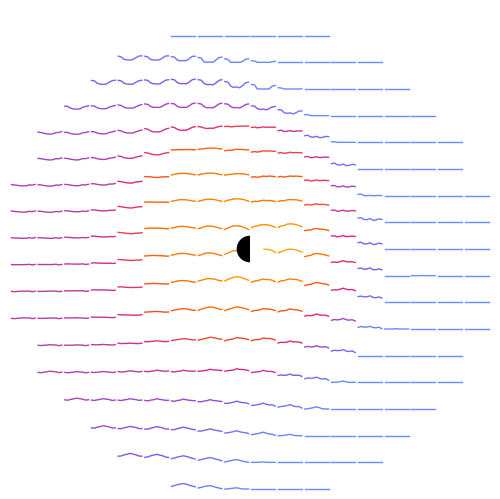

In [50]:
fig, ax = plt.subplots()
ax.set_aspect("equal")


def cell_axes(ax, col, row):
    x = -18 + 2 * col
    y = -18 + 2 * row

    child = ax.inset_axes(
        [x, y, 2, 2],
        transform=ax.transData
    )
    child.set_axis_off()
    return child

def pred_point(x, y):
    r = np.hypot(x, y) * 6378

    if r == 0:
        raise ValueError("x = z = 0 gives an undefined latitude.")

    lat = 0
    mlt = (np.atan2(y, x) * 12 / np.pi + 12) % 24

    sin_mlat = np.sin(lat)
    sin_mlt_cos_mlat = np.sin(mlt * np.pi / 12) * np.cos(lat)
    cos_mlt_cos_mlat = np.cos(mlt * np.pi / 12) * np.cos(lat)

    # One spatial point for every timestamp in omni_time
    n_times = len(omni_time)

    model_input = pd.DataFrame(
        {
            "RAD": np.full(n_times, r),
            "sinMLAT": np.full(n_times, sin_mlat),
            "sinMLTcosMLAT": np.full(n_times, sin_mlt_cos_mlat),
            "cosMLTcosMLAT": np.full(n_times, cos_mlt_cos_mlat),
            "lg E": np.full(n_times, np.log10(energy)),
            "PS": np.full(n_times, tilt),
        },
        index=omni_time.index,
    )

    model_input.index.name = "Time tag"
    model_input = model_input.merge(
        omni_time,
        left_index=True,
        right_index=True,
    )

    model_input = model_input[scaler.feature_names_in_]
    model_input.loc[:, :] = scaler.transform(model_input)

    base_features = [1, 2, 3, 4, 0, 5]

    _, flux = model.predict(
        [
            model_input.iloc[:, base_features],
            model_input,
        ],
        batch_size=2**17,
        verbose=False,
    )

    # Shape: (number of timestamps, 9)
    flux = relu(flux)

    return flux

for col in range(18):
    for row in range(18):
        cell_ax = cell_axes(ax, col=col, row=row)

        x = -18 + 2 * col + 1
        y = -18 + 2 * row + 1

        if np.hypot(x, y) > 18:
            continue

        fluxes = pred_point(x, y)[0, :]
        flux_o = omnidir_flux(fluxes)

        # cell_ax.plot(np.arange(10, 180, 20), fluxes, linewidth=2, color=ibm(0), clip_on=False)
        cell_ax.plot(np.arange(10, 180, 20), fluxes, linewidth=1, color=ibm(int(256 * flux_o / 6)), clip_on=False)

        # cell_ax.set_xlim(10, 170)
        cell_ax.set_xlim(0, 180)
        cell_ax.set_ylim(0, 6)

ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none', zorder=100000))
ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none', zorder=100000))

xlim = (-18, 18)
ylim = (-18, 18)

# vertical = ax.vlines(range(-18, 19, 2), ymin=ylim[0], ymax=ylim[1], linewidth=0.5, color="#bcbec0", clip_on=False, alpha=0.6)
# horizontal = ax.hlines(range(-18, 19, 2), xmin=xlim[0], xmax=xlim[1], linewidth=0.5, color="#bcbec0", clip_on=False, alpha=0.6)

# vertical.set_capstyle("butt")
# horizontal.set_capstyle("butt")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

fig.savefig(f'Plots/pads_storm_{str(time).replace(":", "-")}_xy.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

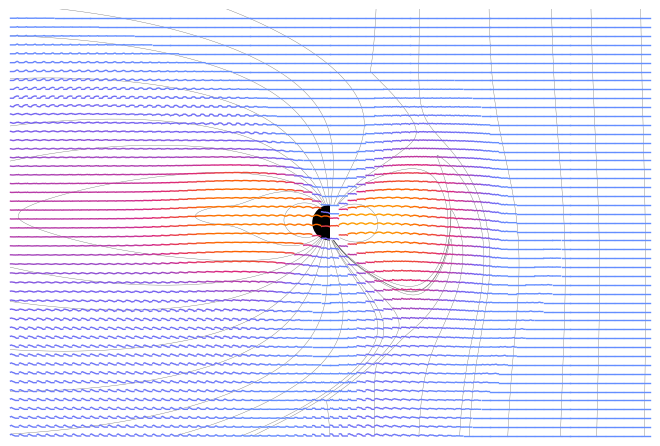

In [ ]:
# High resolution
fig, ax = plt.subplots()
ax.set_aspect("equal")

def cell_axes(ax, col, row):
    x = -18 + 0.5 * col
    y = -12 + 0.5 * row

    child = ax.inset_axes(
        [x, y, 0.5, 0.5],
        transform=ax.transData
    )
    child.set_axis_off()
    return child

def pred_point(x, z):
    r = np.hypot(x, z) * 6378

    if r == 0:
        raise ValueError("x = z = 0 gives an undefined latitude.")

    lat = np.arcsin(z * 6378 / r)
    mlt = 12.0 if x > 0 else 0.0

    sin_mlat = np.sin(lat)
    sin_mlt_cos_mlat = np.sin(mlt * np.pi / 12) * np.cos(lat)
    cos_mlt_cos_mlat = np.cos(mlt * np.pi / 12) * np.cos(lat)

    # One spatial point for every timestamp in omni_time
    n_times = len(omni_time)

    model_input = pd.DataFrame(
        {
            "RAD": np.full(n_times, r),
            "sinMLAT": np.full(n_times, sin_mlat),
            "sinMLTcosMLAT": np.full(n_times, sin_mlt_cos_mlat),
            "cosMLTcosMLAT": np.full(n_times, cos_mlt_cos_mlat),
            "lg E": np.full(n_times, np.log10(energy)),
            "PS": np.full(n_times, tilt),
        },
        index=omni_time.index,
    )

    model_input.index.name = "Time tag"
    model_input = model_input.merge(
        omni_time,
        left_index=True,
        right_index=True,
    )

    model_input = model_input[scaler.feature_names_in_]
    model_input.loc[:, :] = scaler.transform(model_input)

    base_features = [1, 2, 3, 4, 0, 5]

    _, flux = model.predict(
        [
            model_input.iloc[:, base_features],
            model_input,
        ],
        batch_size=2**17,
        verbose=False,
    )

    # Shape: (number of timestamps, 9)
    flux = relu(flux)

    return flux

for col in range(18*4):
    for row in range(12*4):
        cell_ax = cell_axes(ax, col=col, row=row)

        x = -18 + 0.5 * col + 0.25
        y = -12 + 0.5 * row + 0.25
        fluxes = pred_point(x, y)[0, :]
        flux_o = omnidir_flux(fluxes)

        cell_ax.plot(np.arange(10, 180, 20), fluxes, linewidth=1, color=ibm(int(256 * flux_o / 6)), clip_on=False)
        # cell_ax.plot(np.arange(10, 180, 20), fluxes, linewidth=1, color=ibm(int(256 * (flux_o-4) / 4)), clip_on=False)

        # cell_ax.set_xlim(10, 170)
        cell_ax.set_xlim(0, 180)
        cell_ax.set_ylim(0, 6)
        # cell_ax.set_ylim(7, 8)

ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none', zorder=1))
ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none', zorder=1))

for l in range(len(xxs)):
    ax.plot(xxs[l], zzs[l], linewidth=0.25, alpha=0.6, c='k', zorder=0)

xlim = (-18, 18)
ylim = (-12, 12)

# vertical = ax.vlines(range(-18, 19, 2), ymin=ylim[0], ymax=ylim[1], linewidth=0.25, color="#bcbec0", clip_on=False, alpha=0.6)
# horizontal = ax.hlines(range(-12, 13, 2), xmin=xlim[0], xmax=xlim[1], linewidth=0.25, color="#bcbec0", clip_on=False, alpha=0.6)
# vertical.set_capstyle("butt")
# horizontal.set_capstyle("butt")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

fig.savefig(f'Plots/pads_storm_fine_{str(time).replace(":", "-")}.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

# Spectra

A     = 3.16e+08
E0    = 1 keV
kappa = 4.000


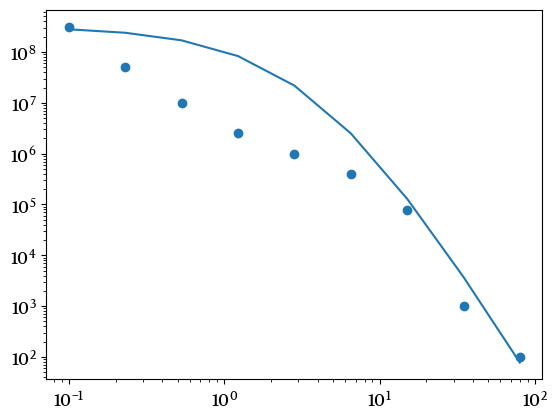

In [149]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Kappa distribution model
def kappa(E, A, E0, kappa):
    return A * (1 + E / (kappa * E0))**(-(kappa + 1))

# Example data (replace with your measurements)
E = np.array([100, 230, 531, 1226, 2828, 6522, 15042, 34689, 80000]) / 1000 # keV
J = 10**np.array([8.5, 7.7, 7.0, 6.4, 6.0, 5.6, 4.9, 3.0 , 2.0]) - 1

# Initial guesses
p0 = [J[0], 1.0, 4.0]

# Fit
params, covariance = curve_fit(
    kappa,
    E,
    J,
    p0=p0,
    bounds=([0, 0, 1.0], [np.inf, np.inf, 100]),
    method="dogbox"
)

A_fit, E0_fit, kappa_fit = params

print(f"A     = {A_fit:.3g}")
print(f"E0    = {E0_fit:.3g} keV")
print(f"kappa = {kappa_fit:.3f}")

plt.scatter(E, J)
plt.plot(E, kappa(E, *params))

plt.xscale("log")
plt.yscale("log")

/tmp/ipykernel_3227444/2444590945.py:11: RuntimeWarning: divide by zero encountered in log10
  return np.log10(kappa(E, A, E0, k))


A     = 1.9e+08
E0    = 0.288 keV
kappa = 1.703


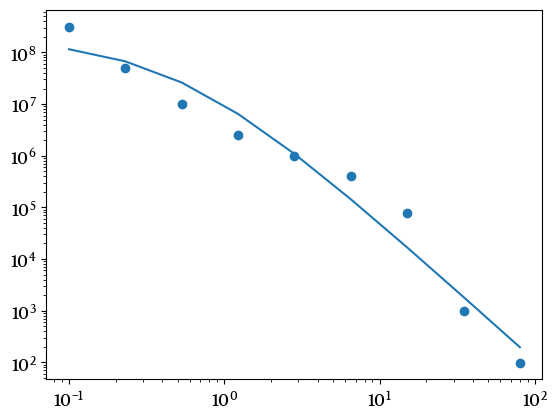

In [173]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Kappa distribution
def kappa(E, A, E0, k):
    return A * (1 + E / (k * E0))**(-(k + 1))

# Model in log10 space
def log_kappa(E, A, E0, k):
    return np.log10(kappa(E, A, E0, k))

E = np.array([100, 230, 531, 1226, 2828, 6522, 15042, 34689, 80000]) / 1000
J = 10**np.array([8.5, 7.7, 7.0, 6.4, 6.0, 5.6, 4.9, 3.0, 2.0]) - 1
# J = 10**np.array([8.5, 7.7, 7.0, 6.4, 6.0, 5.6, 4.9, 0, 0]) - 1

logJ = np.log10(J)

p0 = [J[0], 1.0, 4.0]

mask = J > 0

params, covariance = curve_fit(
    log_kappa,
    E[mask],
    np.log10(J[mask]),
    p0=p0,
    bounds=([0, 0, 0.0], [np.inf, np.inf, 100]),
    method="dogbox"
)

A_fit, E0_fit, kappa_fit = params

print(f"A     = {A_fit:.3g}")
print(f"E0    = {E0_fit:.3g} keV")
print(f"kappa = {kappa_fit:.3f}")

plt.scatter(E, J)
plt.plot(E, kappa(E, *params))

plt.xscale("log")
plt.yscale("log")
plt.show()

In [204]:
def log_kappa(E, A, E0, k):
    return np.log10(A * (1 + E / (k * E0))**(-(k + 1)))

def fit_kappa(energy, flux):
    log_flux = np.log10(flux)

    p0 = [J[0], 1.0, 4.0]

    mask = flux > 0
    params, _ = curve_fit(log_kappa, energy[mask], log_flux[mask], p0=p0,
        # bounds=([0, 0, 0.0], [np.inf, np.inf, 100]),
        method="dogbox"
        )

    return params

fit_kappa(E, J)

/tmp/ipykernel_3227444/1846511813.py:2: RuntimeWarning: divide by zero encountered in log10
  return np.log10(A * (1 + E / (k * E0))**(-(k + 1)))


array([1.90095021e+08, 2.88471247e-01, 1.70306325e+00])

In [308]:
np.degrees(np.atan(-2))

np.float64(-63.43494882292201)

In [44]:
10 ** np.linspace(
    np.log10(100),
    np.log10(80000),
    13,
)

array([  100.        ,   174.55173325,   304.68307579,   531.82958969,
         928.31776672,  1620.39475184,  2828.42712475,  4937.06856982,
        8617.73876013, 15042.41237235, 26256.79151782, 45831.68468893,
       80000.        ])

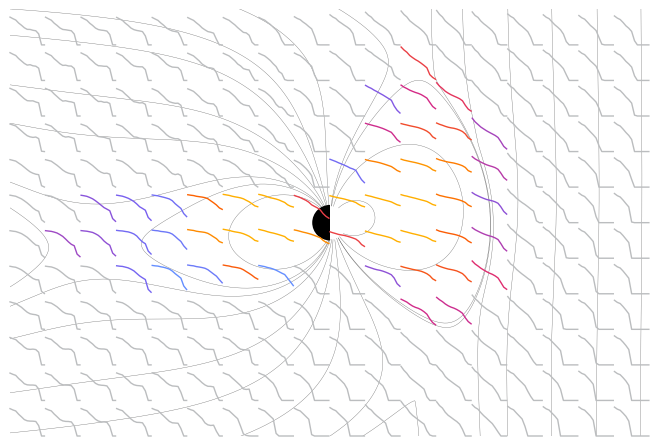

In [18]:
fig, ax = plt.subplots()
ax.set_aspect("equal")

# 30 logarithmically spaced energies from 100 to 80,000
energies = 10 ** np.linspace(
    np.log10(100),
    np.log10(80000),
    # 9,
    13,
)


def cell_axes(ax, col, row):
    x = -18 + 2 * col
    y = -12 + 2 * row

    child = ax.inset_axes(
        [x, y, 2, 2],
        transform=ax.transData,
    )
    child.set_axis_off()
    return child


def pred_omnidirectional_spectrum(x, z, time_index=0):
    """
    Predict omnidirectional flux as a function of energy at one spatial
    point and one timestamp.

    Returns
    -------
    flux_o : ndarray, shape (len(energies),)
        Omnidirectional flux at each energy.
    """
    r = np.hypot(x, z) * 6378

    if r == 0:
        raise ValueError("x = z = 0 gives an undefined latitude.")

    lat = np.arcsin(z * 6378 / r)
    mlt = 12.0 if x > 0 else 0.0

    sin_mlat = np.sin(lat)
    sin_mlt_cos_mlat = np.sin(mlt * np.pi / 12) * np.cos(lat)
    cos_mlt_cos_mlat = np.cos(mlt * np.pi / 12) * np.cos(lat)

    n_energies = len(energies)

    # Select one OMNI timestamp and repeat it for every energy.
    omni_row = omni_time.iloc[[time_index]]
    omni_energy = pd.DataFrame(
        np.repeat(omni_row.to_numpy(), n_energies, axis=0),
        columns=omni_row.columns,
    )

    model_input = pd.DataFrame(
        {
            "RAD": np.full(n_energies, r),
            "sinMLAT": np.full(n_energies, sin_mlat),
            "sinMLTcosMLAT": np.full(
                n_energies,
                sin_mlt_cos_mlat,
            ),
            "cosMLTcosMLAT": np.full(
                n_energies,
                cos_mlt_cos_mlat,
            ),
            "lg E": np.log10(energies),
            "PS": np.full(n_energies, tilt),
        }
    )

    model_input = pd.concat(
        [
            model_input.reset_index(drop=True),
            omni_energy.reset_index(drop=True),
        ],
        axis=1,
    )

    model_input = model_input[scaler.feature_names_in_]

    scaled_input = pd.DataFrame(
        scaler.transform(model_input),
        columns=model_input.columns,
        index=model_input.index,
    )

    base_features = [1, 2, 3, 4, 0, 5]

    _, directional_flux = model.predict(
        [
            scaled_input.iloc[:, base_features],
            scaled_input,
        ],
        batch_size=2**17,
        verbose=False,
    )

    # Shape: (number of energies, 9)
    directional_flux = np.asarray(relu(directional_flux))

    # Convert each set of nine directional fluxes into one
    # omnidirectional value.
    flux_o = np.array(
        [omnidir_flux(flux) for flux in directional_flux]
    )

    return flux_o


for col in range(18):
    for row in range(12):
        cell_ax = cell_axes(ax, col=col, row=row)

        x = -18 + 2 * col + 1
        z = -12 + 2 * row + 1

        flux_o = pred_omnidirectional_spectrum(
            x,
            z,
            time_index=0,
        )

        # gamma = (flux_o[-1] - flux_o[0]) / (np.log10(energies[-1]) - np.log10(energies[0]))
        gamma = None
        # if flux_o[-1] > 0 and flux_o[-2] > 0:
        if flux_o[-1] > np.log10(2) and flux_o[-2] > np.log10(2):
            # flux_r = np.log10(10**flux_o[-1] - 1)
            # flux_l = np.log10(10**flux_o[-2] - 1)
            # gamma = (flux_r - flux_l) / (np.log10(energies[-1]) - np.log10(energies[-2]))
            gamma = (flux_o[-1] - flux_o[-2]) / (np.log10(energies[-1]) - np.log10(energies[-2]))

        # def least_squares_line(points):
        #     n = len(points)
        #     sx = sum(x for x, _ in points)
        #     sy = sum(y for _, y in points)
        #     sxx = sum(x * x for x, _ in points)
        #     sxy = sum(x * y for x, y in points)

        #     m = (n * sxy - sx * sy) / (n * sxx - sx * sx)
        #     b = (sy - m * sx) / n
        #     return m, b

        # gamma, _ = least_squares_line([(np.log10(energies[-3]), flux_o[-3]), (np.log10(energies[-2]), flux_o[-2]), (np.log10(energies[-1]), flux_o[-1])])

        # print(gamma)

        gamma_min = -4
        gamma_max = -1
        cell_ax.plot(
            energies,
            flux_o,
            linewidth=1,
            color=ibm(int(np.clip(255 * (gamma - gamma_min) / (gamma_max - gamma_min), 0, 255))) if not gamma is None else "#bbbdbf",
            clip_on=False,
        )

        cell_ax.set_xscale("log")
        # cell_ax.set_xlim(energies[0], energies[-1])
        cell_ax.set_xlim(1e2, 1e5)

        cell_ax.set_ylim(0, 10)


ax.add_patch(
    Wedge(
        (0, 0),
        1,
        -90,
        90,
        facecolor="w",
        edgecolor="none",
        zorder=1,
    )
)
ax.add_patch(
    Wedge(
        (0, 0),
        1,
        90,
        270,
        facecolor="k",
        edgecolor="none",
        zorder=1,
    )
)

for xx, zz in zip(xxs, zzs):
    ax.plot(
        xx,
        zz,
        linewidth=0.25,
        alpha=0.6,
        color="k",
    )

xlim = (-18, 18)
ylim = (-12, 12)

# vertical = ax.vlines(
#     range(-18, 19, 2),
#     ymin=ylim[0],
#     ymax=ylim[1],
#     linewidth=0.5,
#     color="#bcbec0",
#     clip_on=False,
#     alpha=0.6,
# )
# horizontal = ax.hlines(
#     range(-12, 13, 2),
#     xmin=xlim[0],
#     xmax=xlim[1],
#     linewidth=0.5,
#     color="#bcbec0",
#     clip_on=False,
#     alpha=0.6,
# )

# vertical.set_capstyle("butt")
# horizontal.set_capstyle("butt")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1,
)

fig.savefig(f'Plots/gamma_storm_{str(time).replace(":", "-")}.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

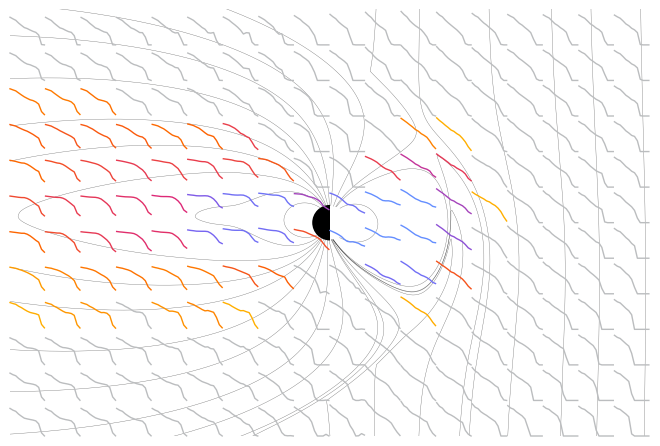

In [ ]:
fig, ax = plt.subplots()
ax.set_aspect("equal")

# 30 logarithmically spaced energies from 100 to 80,000
energies = 10 ** np.linspace(
    np.log10(100),
    np.log10(80000),
    # 9,
    13,
)


def cell_axes(ax, col, row):
    x = -18 + 2 * col
    y = -12 + 2 * row

    child = ax.inset_axes(
        [x, y, 2, 2],
        transform=ax.transData,
    )
    child.set_axis_off()
    return child


def pred_omnidirectional_spectrum(x, z, time_index=0):
    """
    Predict omnidirectional flux as a function of energy at one spatial
    point and one timestamp.

    Returns
    -------
    flux_o : ndarray, shape (len(energies),)
        Omnidirectional flux at each energy.
    """
    r = np.hypot(x, z) * 6378

    if r == 0:
        raise ValueError("x = z = 0 gives an undefined latitude.")

    lat = np.arcsin(z * 6378 / r)
    mlt = 12.0 if x > 0 else 0.0

    sin_mlat = np.sin(lat)
    sin_mlt_cos_mlat = np.sin(mlt * np.pi / 12) * np.cos(lat)
    cos_mlt_cos_mlat = np.cos(mlt * np.pi / 12) * np.cos(lat)

    n_energies = len(energies)

    # Select one OMNI timestamp and repeat it for every energy.
    omni_row = omni_time.iloc[[time_index]]
    omni_energy = pd.DataFrame(
        np.repeat(omni_row.to_numpy(), n_energies, axis=0),
        columns=omni_row.columns,
    )

    model_input = pd.DataFrame(
        {
            "RAD": np.full(n_energies, r),
            "sinMLAT": np.full(n_energies, sin_mlat),
            "sinMLTcosMLAT": np.full(
                n_energies,
                sin_mlt_cos_mlat,
            ),
            "cosMLTcosMLAT": np.full(
                n_energies,
                cos_mlt_cos_mlat,
            ),
            "lg E": np.log10(energies),
            "PS": np.full(n_energies, tilt),
        }
    )

    model_input = pd.concat(
        [
            model_input.reset_index(drop=True),
            omni_energy.reset_index(drop=True),
        ],
        axis=1,
    )

    model_input = model_input[scaler.feature_names_in_]

    scaled_input = pd.DataFrame(
        scaler.transform(model_input),
        columns=model_input.columns,
        index=model_input.index,
    )

    base_features = [1, 2, 3, 4, 0, 5]

    _, directional_flux = model.predict(
        [
            scaled_input.iloc[:, base_features],
            scaled_input,
        ],
        batch_size=2**17,
        verbose=False,
    )

    # Shape: (number of energies, 9)
    directional_flux = np.asarray(relu(directional_flux))

    # Convert each set of nine directional fluxes into one
    # omnidirectional value.
    flux_o = np.array(
        [omnidir_flux(flux) for flux in directional_flux]
    )

    return flux_o


for col in range(18):
    for row in range(12):
        cell_ax = cell_axes(ax, col=col, row=row)

        x = -18 + 2 * col + 1
        z = -12 + 2 * row + 1

        flux_o = pred_omnidirectional_spectrum(
            x,
            z,
            time_index=0,
        )

        # gamma = (flux_o[-1] - flux_o[0]) / (np.log10(energies[-1]) - np.log10(energies[0]))
        gamma = None
        # if flux_o[-1] > 0 and flux_o[-2] > 0:
        if flux_o[-1] > np.log10(2) and flux_o[-2] > np.log10(2):
            # flux_r = np.log10(10**flux_o[-1] - 1)
            # flux_l = np.log10(10**flux_o[-2] - 1)
            # gamma = (flux_r - flux_l) / (np.log10(energies[-1]) - np.log10(energies[-2]))
            # gamma = (flux_o[-1] - flux_o[-2]) / (np.log10(energies[-1]) - np.log10(energies[-2]))
            gamma = (np.log10(10**flux_o[-1] - 1) - np.log10(10**flux_o[-2] - 1)) / (np.log10(energies[-1]) - np.log10(energies[-2]))

            gamma = -gamma

        # def least_squares_line(points):
        #     n = len(points)
        #     sx = sum(x for x, _ in points)
        #     sy = sum(y for _, y in points)
        #     sxx = sum(x * x for x, _ in points)
        #     sxy = sum(x * y for x, y in points)

        #     m = (n * sxy - sx * sy) / (n * sxx - sx * sx)
        #     b = (sy - m * sx) / n
        #     return m, b

        # gamma, _ = least_squares_line([(np.log10(energies[-3]), flux_o[-3]), (np.log10(energies[-2]), flux_o[-2]), (np.log10(energies[-1]), flux_o[-1])])

        # print(gamma)


        gamma_min = 1
        gamma_max = 4
        cell_ax.plot(
            energies,
            flux_o,
            linewidth=1,
            color=ibm(int(np.clip(255 * (gamma - gamma_min) / (gamma_max - gamma_min), 0, 255))) if not gamma is None else "#bbbdbf",
            clip_on=False,
        )

        cell_ax.set_xscale("log")
        # cell_ax.set_xlim(energies[0], energies[-1])
        cell_ax.set_xlim(1e2, 1e5)

        cell_ax.set_ylim(0, 10)


ax.add_patch(
    Wedge(
        (0, 0),
        1,
        -90,
        90,
        facecolor="w",
        edgecolor="none",
        zorder=1,
    )
)
ax.add_patch(
    Wedge(
        (0, 0),
        1,
        90,
        270,
        facecolor="k",
        edgecolor="none",
        zorder=1,
    )
)

for xx, zz in zip(xxs, zzs):
    ax.plot(
        xx,
        zz,
        linewidth=0.25,
        alpha=0.6,
        color="k",
    )

xlim = (-18, 18)
ylim = (-12, 12)

# vertical = ax.vlines(
#     range(-18, 19, 2),
#     ymin=ylim[0],
#     ymax=ylim[1],
#     linewidth=0.5,
#     color="#bcbec0",
#     clip_on=False,
#     alpha=0.6,
# )
# horizontal = ax.hlines(
#     range(-12, 13, 2),
#     xmin=xlim[0],
#     xmax=xlim[1],
#     linewidth=0.5,
#     color="#bcbec0",
#     clip_on=False,
#     alpha=0.6,
# )

# vertical.set_capstyle("butt")
# horizontal.set_capstyle("butt")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1,
)

# fig.savefig(f'Plots/minus_gamma_storm_{str(time).replace(":", "-")}.pdf', bbox_inches='tight', pad_inches=0)
fig.savefig(f'Plots/minus_gamma_true_storm_{str(time).replace(":", "-")}.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [37]:
np.degrees(np.atan(100))

np.float64(89.42706130231652)

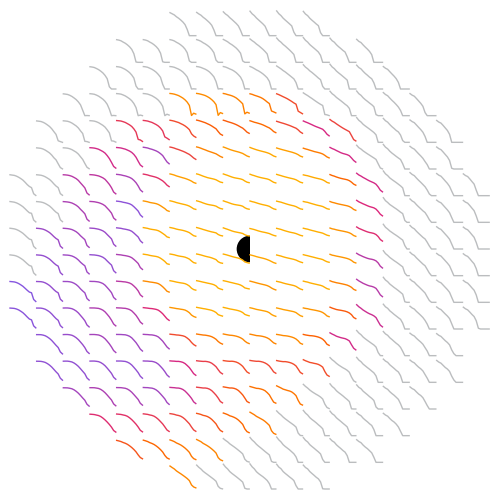

In [44]:
fig, ax = plt.subplots()
ax.set_aspect("equal")

# 30 logarithmically spaced energies from 100 to 80,000
energies = 10 ** np.linspace(
    np.log10(100),
    np.log10(80000),
    # 9,
    13,
)


def cell_axes(ax, col, row):
    x = -18 + 2 * col
    y = -18 + 2 * row

    child = ax.inset_axes(
        [x, y, 2, 2],
        transform=ax.transData,
    )
    child.set_axis_off()
    return child


def pred_omnidirectional_spectrum(x, z, time_index=0):
    """
    Predict omnidirectional flux as a function of energy at one spatial
    point and one timestamp.

    Returns
    -------
    flux_o : ndarray, shape (len(energies),)
        Omnidirectional flux at each energy.
    """
    r = np.hypot(x, z) * 6378

    if r == 0:
        raise ValueError("x = z = 0 gives an undefined latitude.")

    lat = 0
    mlt = (np.atan2(y, x) * 12 / np.pi + 12) % 24

    sin_mlat = np.sin(lat)
    sin_mlt_cos_mlat = np.sin(mlt * np.pi / 12) * np.cos(lat)
    cos_mlt_cos_mlat = np.cos(mlt * np.pi / 12) * np.cos(lat)

    n_energies = len(energies)

    # Select one OMNI timestamp and repeat it for every energy.
    omni_row = omni_time.iloc[[time_index]]
    omni_energy = pd.DataFrame(
        np.repeat(omni_row.to_numpy(), n_energies, axis=0),
        columns=omni_row.columns,
    )

    model_input = pd.DataFrame(
        {
            "RAD": np.full(n_energies, r),
            "sinMLAT": np.full(n_energies, sin_mlat),
            "sinMLTcosMLAT": np.full(
                n_energies,
                sin_mlt_cos_mlat,
            ),
            "cosMLTcosMLAT": np.full(
                n_energies,
                cos_mlt_cos_mlat,
            ),
            "lg E": np.log10(energies),
            "PS": np.full(n_energies, tilt),
        }
    )

    model_input = pd.concat(
        [
            model_input.reset_index(drop=True),
            omni_energy.reset_index(drop=True),
        ],
        axis=1,
    )

    model_input = model_input[scaler.feature_names_in_]

    scaled_input = pd.DataFrame(
        scaler.transform(model_input),
        columns=model_input.columns,
        index=model_input.index,
    )

    base_features = [1, 2, 3, 4, 0, 5]

    _, directional_flux = model.predict(
        [
            scaled_input.iloc[:, base_features],
            scaled_input,
        ],
        batch_size=2**17,
        verbose=False,
    )

    # Shape: (number of energies, 9)
    directional_flux = np.asarray(relu(directional_flux))

    # Convert each set of nine directional fluxes into one
    # omnidirectional value.
    flux_o = np.array(
        [omnidir_flux(flux) for flux in directional_flux]
    )

    return flux_o


for col in range(18):
    for row in range(18):
        cell_ax = cell_axes(ax, col=col, row=row)

        x = -18 + 2 * col + 1
        y = -18 + 2 * row + 1

        if np.hypot(x, y) > 18:
            continue

        flux_o = pred_omnidirectional_spectrum(
            x,
            y,
            time_index=0,
        )

        gamma = None
        if flux_o[-1] > np.log10(2) and flux_o[-2] > np.log10(2):
            gamma = (flux_o[-1] - flux_o[-2]) / (np.log10(energies[-1]) - np.log10(energies[-2]))

        gamma_min = -4
        gamma_max = -1
        cell_ax.plot(
            energies,
            flux_o,
            linewidth=1,
            color=ibm(int(np.clip(255 * (gamma - gamma_min) / (gamma_max - gamma_min), 0, 255))) if not gamma is None else "#bbbdbf",
            clip_on=False,
        )

        cell_ax.set_xscale("log")
        cell_ax.set_xlim(1e2, 1e5)

        cell_ax.set_ylim(0, 10)


ax.add_patch(
    Wedge(
        (0, 0),
        1,
        -90,
        90,
        facecolor="w",
        edgecolor="none",
        zorder=1,
    )
)
ax.add_patch(
    Wedge(
        (0, 0),
        1,
        90,
        270,
        facecolor="k",
        edgecolor="none",
        zorder=1,
    )
)

xlim = (-18, 18)
ylim = (-18, 18)

# vertical = ax.vlines(
#     range(-18, 19, 2),
#     ymin=ylim[0],
#     ymax=ylim[1],
#     linewidth=0.5,
#     color="#bcbec0",
#     clip_on=False,
#     alpha=0.6,
# )
# horizontal = ax.hlines(
#     range(-18, 19, 2),
#     xmin=xlim[0],
#     xmax=xlim[1],
#     linewidth=0.5,
#     color="#bcbec0",
#     clip_on=False,
#     alpha=0.6,
# )

# vertical.set_capstyle("butt")
# horizontal.set_capstyle("butt")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1,
)

fig.savefig(f'Plots/gamma_storm_{str(time).replace(":", "-")}_xy.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

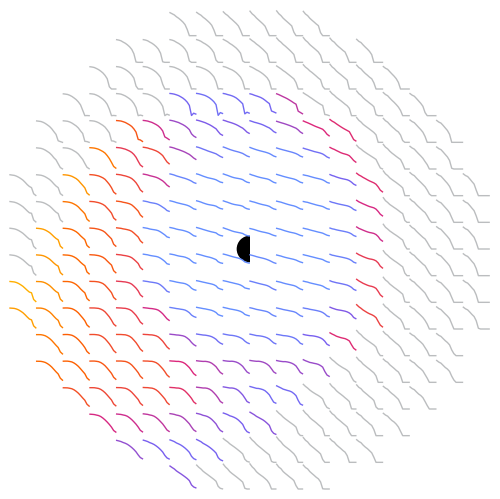

In [87]:
fig, ax = plt.subplots()
ax.set_aspect("equal")

# 30 logarithmically spaced energies from 100 to 80,000
energies = 10 ** np.linspace(
    np.log10(100),
    np.log10(80000),
    # 9,
    13,
)


def cell_axes(ax, col, row):
    x = -18 + 2 * col
    y = -18 + 2 * row

    child = ax.inset_axes(
        [x, y, 2, 2],
        transform=ax.transData,
    )
    child.set_axis_off()
    return child


def pred_omnidirectional_spectrum(x, z, time_index=0):
    """
    Predict omnidirectional flux as a function of energy at one spatial
    point and one timestamp.

    Returns
    -------
    flux_o : ndarray, shape (len(energies),)
        Omnidirectional flux at each energy.
    """
    r = np.hypot(x, z) * 6378

    if r == 0:
        raise ValueError("x = z = 0 gives an undefined latitude.")

    lat = 0
    mlt = (np.atan2(y, x) * 12 / np.pi + 12) % 24

    sin_mlat = np.sin(lat)
    sin_mlt_cos_mlat = np.sin(mlt * np.pi / 12) * np.cos(lat)
    cos_mlt_cos_mlat = np.cos(mlt * np.pi / 12) * np.cos(lat)

    n_energies = len(energies)

    # Select one OMNI timestamp and repeat it for every energy.
    omni_row = omni_time.iloc[[time_index]]
    omni_energy = pd.DataFrame(
        np.repeat(omni_row.to_numpy(), n_energies, axis=0),
        columns=omni_row.columns,
    )

    model_input = pd.DataFrame(
        {
            "RAD": np.full(n_energies, r),
            "sinMLAT": np.full(n_energies, sin_mlat),
            "sinMLTcosMLAT": np.full(
                n_energies,
                sin_mlt_cos_mlat,
            ),
            "cosMLTcosMLAT": np.full(
                n_energies,
                cos_mlt_cos_mlat,
            ),
            "lg E": np.log10(energies),
            "PS": np.full(n_energies, tilt),
        }
    )

    model_input = pd.concat(
        [
            model_input.reset_index(drop=True),
            omni_energy.reset_index(drop=True),
        ],
        axis=1,
    )

    model_input = model_input[scaler.feature_names_in_]

    scaled_input = pd.DataFrame(
        scaler.transform(model_input),
        columns=model_input.columns,
        index=model_input.index,
    )

    base_features = [1, 2, 3, 4, 0, 5]

    _, directional_flux = model.predict(
        [
            scaled_input.iloc[:, base_features],
            scaled_input,
        ],
        batch_size=2**17,
        verbose=False,
    )

    # Shape: (number of energies, 9)
    directional_flux = np.asarray(relu(directional_flux))

    # Convert each set of nine directional fluxes into one
    # omnidirectional value.
    flux_o = np.array(
        [omnidir_flux(flux) for flux in directional_flux]
    )

    return flux_o


for col in range(18):
    for row in range(18):
        cell_ax = cell_axes(ax, col=col, row=row)

        x = -18 + 2 * col + 1
        y = -18 + 2 * row + 1

        if np.hypot(x, y) > 18:
            continue

        flux_o = pred_omnidirectional_spectrum(
            x,
            y,
            time_index=0,
        )

        gamma = None
        if flux_o[-1] > np.log10(2) and flux_o[-2] > np.log10(2):
            # gamma = (flux_o[-1] - flux_o[-2]) / (np.log10(energies[-1]) - np.log10(energies[-2]))
            gamma = (np.log10(10**flux_o[-1] - 1) - np.log10(10**flux_o[-2] - 1)) / (np.log10(energies[-1]) - np.log10(energies[-2]))

            gamma = -gamma

        gamma_min = 1
        gamma_max = 4
        cell_ax.plot(
            energies,
            flux_o,
            linewidth=1,
            color=ibm(int(np.clip(255 * (gamma - gamma_min) / (gamma_max - gamma_min), 0, 255))) if not gamma is None else "#bbbdbf",
            clip_on=False,
        )

        cell_ax.set_xscale("log")
        cell_ax.set_xlim(1e2, 1e5)

        cell_ax.set_ylim(0, 10)


ax.add_patch(
    Wedge(
        (0, 0),
        1,
        -90,
        90,
        facecolor="w",
        edgecolor="none",
        zorder=1,
    )
)
ax.add_patch(
    Wedge(
        (0, 0),
        1,
        90,
        270,
        facecolor="k",
        edgecolor="none",
        zorder=1,
    )
)

xlim = (-18, 18)
ylim = (-18, 18)

# vertical = ax.vlines(
#     range(-18, 19, 2),
#     ymin=ylim[0],
#     ymax=ylim[1],
#     linewidth=0.5,
#     color="#bcbec0",
#     clip_on=False,
#     alpha=0.6,
# )
# horizontal = ax.hlines(
#     range(-18, 19, 2),
#     xmin=xlim[0],
#     xmax=xlim[1],
#     linewidth=0.5,
#     color="#bcbec0",
#     clip_on=False,
#     alpha=0.6,
# )

# vertical.set_capstyle("butt")
# horizontal.set_capstyle("butt")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1,
)

# fig.savefig(f'Plots/minus_gamma_storm_{str(time).replace(":", "-")}_xy.pdf', bbox_inches='tight', pad_inches=0)
fig.savefig(f'Plots/minus_gamma_true_storm_{str(time).replace(":", "-")}_xy.pdf', bbox_inches='tight', pad_inches=0)
plt.show()